![](https://miro.medium.com/v2/resize:fit:512/1*IMGOKBIN8qkOBt5CH55NSw.png)

# Section 2: Architectures in PyTorch

## What we are going to cover


## Lesson 1: Loading and Preprocessing Image Datasets with PyTorch

In this tutorial, we will cover the essential steps to load and preprocess image datasets using PyTorch. We'll use a real-world business case related dataset to make it practical and relevant. The dataset we'll use is the "Intel Image Classification" dataset, which contains images of various natural scenes categorized into six classes.

Dataset link: (https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data)


### 1. What is Computer Vision?

Computer vision is a field of artificial intelligence that enables computers to interpret and make decisions based on visual data.

### Importing libraries


In [ ]:
# !pip install torchvision

In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

### 3. Loading the Dataset
The "Intel Image Classification" dataset can be downloaded from Kaggle. We will use the torchvision.datasets.ImageFolder to load the dataset.

First, download the dataset from Kaggle and unzip it to your working directory.

In [2]:
data_dir_train = r'/Users/teslim/TeslimWorkSpace/MainClass/3-Mainclass-LLM/llm-1-PyTorch/SuperdataScience_PyTorch_From Zero to Hero/data/seg_train/seg_train'
data_dir_test = r'/Users/teslim/TeslimWorkSpace/MainClass/3-Mainclass-LLM/llm-1-PyTorch/SuperdataScience_PyTorch_From Zero to Hero/data/seg_test/seg_test'

In [6]:
local_dir_train = "seg_train/seg_train"
local_dir_test = "seg_test/seg_test"

### 4. Preprocessing the Dataset
Preprocessing is an essential step in preparing the data for training. Common preprocessing steps include resizing, normalization, and data augmentation.

Define the transformations:

In [7]:
transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#### Understanding the Transform Pipeline

This code snippet demonstrates a common preprocessing pipeline for image data in PyTorch, particularly when working with computer vision models. Let me break down what's happening here.

The `transforms.Compose()` function creates a sequential chain of image transformations that will be applied to input images in the specified order. Think of it like an assembly line where each transformation is a station that modifies the image before passing it to the next step.

The first transformation, `transforms.Resize((128, 128))`, resizes all input images to a fixed size of 128×128 pixels. This standardization is crucial because neural networks expect consistent input dimensions across all samples in a batch. Without this step, images of varying sizes would cause tensor dimension mismatches during training or inference.

Next, `transforms.ToTensor()` converts the PIL Image or numpy array (typically with pixel values ranging from 0-255) into a PyTorch tensor with values normalized to the range [0, 1]. This transformation also reorders the dimensions from the typical image format (Height × Width × Channels) to PyTorch's expected format (Channels × Height × Width).

The final transformation, `transforms.Normalize()`, applies standardization using ImageNet statistics. The mean values `[0.485, 0.456, 0.406]` and standard deviation values `[0.229, 0.224, 0.225]` correspond to the RGB channels respectively. This normalization formula `(pixel - mean) / std` transforms the [0, 1] range to approximately [-2, 2], centering the data around zero. Using ImageNet statistics is a standard practice when working with pre-trained models, as it ensures your input data has the same distribution the model was originally trained on.

**Important Note**: The order of these transforms matters significantly. Always apply `ToTensor()` before `Normalize()`, as the normalization expects tensor input with values in [0, 1] range, not the original [0, 255] pixel values.

### 5. Creating Data Loaders
Data loaders in PyTorch help in efficiently loading data during training. We will create a data loader for our training dataset.

In [8]:
dataset = datasets.ImageFolder(root=data_dir_train, transform=transforms)
dataset_test = datasets.ImageFolder(root=data_dir_test, transform=transforms)

#### Understanding ImageFolder Dataset Loading

This code snippet demonstrates how to create PyTorch datasets from image directories using the `ImageFolder` class, which is one of the most convenient ways to load image classification datasets in PyTorch.

The `datasets.ImageFolder` is a generic data loader class that expects your data to be organized in a specific directory structure. It assumes that images are arranged in subfolders, where each subfolder represents a different class or category. For example, if you're working with the Intel Image Classification dataset mentioned in your notebook, the directory structure would look like `root/class_name/image_files`, such as `seg_train/buildings/image1.jpg`, `seg_train/forest/image2.jpg`, etc.

The first line creates a training dataset by pointing to the `data_dir_train` directory (which appears to be the full path to your training data) and applies the previously defined `transforms` pipeline to each image as it's loaded. This means every image will be automatically resized to 128×128 pixels, converted to a tensor, and normalized using ImageNet statistics before being fed into your model.

Similarly, the second line creates a test dataset using the same transformation pipeline but pointing to the test directory (`data_dir_test`). It's important to note that both training and test datasets use the same transforms in this case, which is typically what you want for evaluation - you want your test data to undergo the same preprocessing steps as your training data to ensure consistency.

**Key benefit**: The `ImageFolder` class automatically assigns integer labels to each class based on the alphabetical order of the folder names and creates a mapping that you can access via `dataset.classes` and `dataset.class_to_idx`. This eliminates the need to manually create labels for your images, making it extremely efficient for organizing and loading image classification datasets.

**Important Note**: Make sure your directory structure is correct and that the `transform` parameter matches what your model expects. If the transforms are inconsistent between training and testing, you might see a significant drop in model performance during evaluation.

In [ ]:
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

In [12]:
train_size, val_size

(12630, 1404)

In [13]:
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

#### Understanding Dataset Splitting with random_split

This code snippet demonstrates how to split a PyTorch dataset into training and validation subsets using the `random_split` function, which is a crucial step in machine learning workflows for creating proper data splits.

The `torch.utils.data.random_split()` function takes your original dataset and randomly divides it into non-overlapping subsets based on the lengths you specify. In this case, it's splitting the `dataset` (which was created from the training directory using `ImageFolder`) into two parts: `train_dataset` and `val_dataset`. The sizes are determined by the `train_size` and `val_size` variables that were calculated earlier as 90% and 10% of the original dataset respectively.

Under the hood, `random_split` creates a random permutation of indices from 0 to the dataset length, then assigns different ranges of these shuffled indices to each subset. This ensures that the split is truly random and that no data points appear in both training and validation sets. The function returns `Subset` objects, which are lightweight wrappers around the original dataset that only expose the assigned indices.

**Key benefit**: This approach is memory-efficient because it doesn't actually duplicate the data. Instead, each subset maintains references to specific indices of the original dataset. When you access an item from `train_dataset` or `val_dataset`, it fetches the corresponding item from the original dataset using the assigned indices.

**Important consideration**: The split is random by default, but you can make it reproducible by passing a `generator` parameter with a fixed seed. This is crucial for experimental reproducibility - without setting a seed, you'll get different train/validation splits each time you run your code, making it difficult to compare results across different runs.

**Critical requirement**: Make sure that `train_size + val_size` equals the length of your original dataset, otherwise the function will raise a `ValueError`. The function is strict about this requirement to prevent accidentally losing or duplicating data during the split process.

In [14]:
train_size +val_size

14034

In [19]:
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)

#### Understanding DataLoaders for Batch Processing

This code snippet demonstrates how to create PyTorch DataLoaders for training and testing datasets, which are essential components for efficiently loading and managing data during the machine learning workflow.

The `DataLoader` class wraps around your datasets and provides a convenient interface for batching, shuffling, and parallel data loading. In the first line, `train_loader` is created using the training dataset with a batch size of 32, meaning it will group 32 images together in each batch for processing. The `shuffle=True` parameter is crucial for training because it randomly reorders the data at each epoch, preventing the model from learning patterns based on the order of samples and improving generalization.

The second line creates `test_loader` for the test dataset, also with a batch size of 32. However, notice that `shuffle=False` is used here, which is the standard practice for evaluation. During testing or validation, you want consistent, reproducible results, so the data should be processed in the same order every time you evaluate your model.

**Key benefits**: DataLoaders handle the complex task of efficiently loading data in batches, which is memory-efficient and allows for faster training through vectorized operations. They also support multiprocessing (via the `num_workers` parameter) to load data in parallel while your GPU is processing the current batch, reducing training time.

**Important consideration**: The choice of batch size (32 in this case) is a hyperparameter that affects both memory usage and training dynamics. Larger batch sizes use more GPU memory but can lead to more stable gradients, while smaller batch sizes use less memory but may result in noisier gradient updates.

**Important Note**: Notice that both loaders use the same batch size but different datasets (`dataset` vs `dataset_test`). This means the training loader will iterate through your training data while the test loader processes your separate test set, ensuring proper evaluation on unseen data.

### 6. Visualizing the Data
Visualizing the data helps in understanding the dataset and verifying that the preprocessing steps are correctly applied.

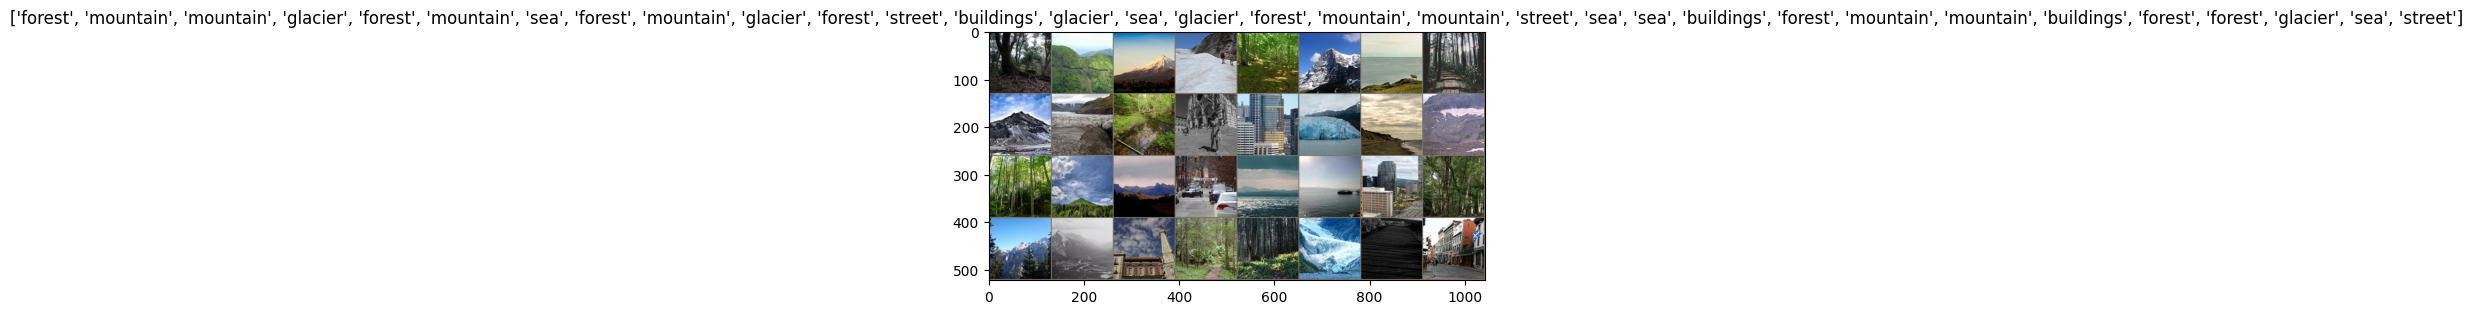

In [20]:
# Function to visualize a batch of images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[dataset.classes[x] for x in classes])

#### Understanding Image Visualization and Denormalization

This code snippet demonstrates a complete workflow for visualizing preprocessed image data from a PyTorch dataset, which is essential for understanding and verifying your data pipeline before training a model.

The `imshow` function is a custom utility designed specifically to display PyTorch tensors that have been normalized using ImageNet statistics. The function performs several critical steps to reverse the preprocessing and make images viewable. First, it converts the PyTorch tensor to a NumPy array using `.numpy()`, then transposes the dimensions from PyTorch's channel-first format (C, H, W) to matplotlib's expected channel-last format (H, W, C) using `.transpose((1, 2, 0))`.

The next crucial step involves denormalizing the image data. Since the images were previously normalized using ImageNet statistics (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), the function reverses this process by applying the inverse transformation: `inp = std * inp + mean`. This converts the normalized values back to the original [0, 1] range that matplotlib expects for image display.

The `np.clip(inp, 0, 1)` operation ensures that any pixel values that might have gone slightly outside the valid range due to floating-point arithmetic are clamped back to the proper [0, 1] bounds. This prevents display artifacts and ensures proper image rendering.

The data loading section uses `next(iter(train_loader))` to fetch a single batch from the training data loader. This is a common pattern for getting a sample batch without iterating through the entire dataset. The function returns both the image tensors (`inputs`) and their corresponding class labels (`classes`).

The `torchvision.utils.make_grid()` function is particularly useful as it arranges multiple images from the batch into a single grid layout for easy visualization. This allows you to see several examples at once rather than displaying them individually, making it efficient to inspect your data quality and transformations.

**Key benefit**: This visualization approach is invaluable for debugging your data pipeline. You can verify that your transformations are working correctly, check image quality, and ensure that the preprocessing hasn't corrupted your data.

**Important note**: The `plt.pause(0.001)` call ensures that the plot updates properly in interactive environments like Jupyter notebooks, allowing the image to render before the function completes.

##  Lesson 2: Understanding and Implementing a Basic CNN

In this tutorial, we will explore Convolutional Neural Networks (CNNs), a class of deep neural networks commonly used for analyzing visual data. We will understand the basic architecture of CNNs and implement a simple CNN model using PyTorch.

### Introduction to CNNs

Convolutional Neural Networks (CNNs) are specialized deep neural networks designed to process structured grid data, such as images. They have shown remarkable performance in tasks like image classification, object detection, and more.

### Understanding CNN Architecture

A typical CNN architecture consists of the following layers:
- **Convolutional Layers:** Apply convolution operations to the input data to extract features.
- **Activation Functions:** Introduce non-linearity into the model.
- **Pooling Layers:** Reduce the spatial dimensions of the data.
- **Fully Connected Layers:** Perform classification based on the extracted features.

### Wait wait, but can we use FCN for images as well? And if not why not?

![](https://i.ibb.co/JKqCYmG/Screenshot-2024-06-22-at-22-46-03.png)


### General architecture of a CNN model


![](https://i.ibb.co/5MckwHJ/Screenshot-2024-06-22-at-22-46-10.png)

### Explanation of CNN operations:


![](https://i.ibb.co/Bz0HNYh/Screenshot-2024-06-22-at-22-46-15.png)

![](https://i.ibb.co/tqp2H8M/Screenshot-2024-06-22-at-22-46-23.png)

![](https://i.ibb.co/NVrRn4z/Screenshot-2024-06-22-at-22-46-29.png)

![](https://i.ibb.co/Mk6qzNZ/Screenshot-2024-06-22-at-22-46-36.png)

![](https://miro.medium.com/v2/resize:fit:1400/0*fnHYnmwI_wmfwGAp.gif)







In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm.notebook import tqdm
device = torch.device("cuda")

In [ ]:
class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        pass

    def forward(self, x):

        return x


###  Training and Evaluating the CNN

To train our model, we need to define a loss function and an optimizer. We'll use Cross-Entropy Loss and the Adam optimizer.


In [ ]:
# Training the model
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 1/5, Loss: 0.7831


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 2/5, Loss: 0.5239


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 3/5, Loss: 0.3750


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 4/5, Loss: 0.2341


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 5/5, Loss: 0.1410


### Evaluation

Finally, let's evaluate our model on the validation set:

In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

Validation Accuracy: 81.40%



## Lesson 3: Layers in CNNs and Implementing Advanced Features

In this tutorial, we will dive deeper into the architecture of Convolutional Neural Networks (CNNs). We will understand the different layers involved in a CNN, such as pooling and fully connected layers, and implement a more advanced CNN model.


### What are pooling layers?

Pooling layers are used in CNNs to decrease general size of an input tensor (or an image). They are acomplising this by simply looking at different image/tensor regions and checking what is the highest value of pixel (ie which color is brighest). We only capture and persever that number and the rest is discarded.

![](https://i.ibb.co/93kVBk0/Screenshot-2024-06-22-at-22-46-59.png)

![](https://i.ibb.co/1JwVn22/Screenshot-2024-06-22-at-22-47-04.png)

![](https://i.ibb.co/QJf3gGx/Screenshot-2024-06-22-at-22-47-09.png)




In [ ]:
class BasicCNNV2(nn.Module):
    def __init__(self):
        super(BasicCNNV2, self).__init__()
        pass

    def forward(self, x):
        pass


###  Training and Evaluating the Improved CNN

Define the loss function and optimizer:

In [ ]:
model = BasicCNNV2()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 1/10, Loss: 0.8936


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 2/10, Loss: 0.5417


  0%|          | 0/439 [00:00<?, ?it/s]

...

Epoch 8/10, Loss: 0.0442


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 9/10, Loss: 0.0435


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 10/10, Loss: 0.0510



### Evaluation

Evaluate the model on the validation set:


In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

Validation Accuracy: 79.77%



## Lesson 4: Data Augmentation and Regularization Techniques

In this tutorial, we will explore advanced techniques to improve the performance of Convolutional Neural Networks (CNNs). These techniques include data augmentation for images and regularization techniques.

### What is Data Augmentation for Images?

Data augmentation is a technique used to artificially expand the size of a training dataset by creating modified versions of images. Common augmentation techniques include:
- Rotation
- Flipping
- Scaling
- Cropping
- Color jitter

Data augmentation helps in improving the robustness of the model by exposing it to a variety of image transformations.
![](https://albumentations.ai/docs/images/introduction/image_augmentation/augmentation.jpg)
### What are Regularization Techniques?

Regularization techniques help in reducing overfitting and improving the generalization of the model. Common regularization techniques include:
- **Dropout:** Randomly sets a fraction of input units to 0 at each update during training time, which helps in preventing overfitting.
- **L2 Regularization:** Adds a penalty equal to the sum of the squared weights to the loss function, which helps in keeping the model weights small.



In [ ]:
# Define the transformations with data augmentation
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load the dataset with the transformations
train_dataset = datasets.ImageFolder(root='seg_train/seg_train', transform=transform_train)
val_dataset = datasets.ImageFolder(root='seg_train/seg_train', transform=transform_val)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Defining upgraded model with all changes

In [ ]:
class BasicCNNV3(nn.Module):
    def __init__(self):
        super(BasicCNNV3, self).__init__()
        pass

    def forward(self, x):
        pass

### Training and Evaluating the Enhanced CNN

Define the loss function and optimizer with L2 regularization:


In [ ]:
# Define the model, loss function, and optimizer
model = BasicCNNV3()
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) #, weight_decay=1e-4)  # L2 regularization

In [ ]:
# Training the model
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 1/10, Loss: 1.0722


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 2/10, Loss: 0.9104


  0%|          | 0/439 [00:00<?, ?it/s]

...

Epoch 8/10, Loss: 0.6888


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 9/10, Loss: 0.6756


  0%|          | 0/439 [00:00<?, ?it/s]

Epoch 10/10, Loss: 0.6533


### Evaluate model

In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

Validation Accuracy: 84.87%



## Lesson 5: Introduction to Sequence Data

In this tutorial, we will explore sequence data, its unique characteristics, and how it differs from image data. We will also touch on basic processing techniques for sequence data using PyTorch.


### Introduction to Sequence Data

Sequence data is a type of data where the order of the elements is significant. Common examples include:
- Text data (sentences, paragraphs)
- Time series data (stock prices, weather data)
- Audio data (speech, music)

### Differences from Image Data

Sequence data differs from image data in several key ways:
- **Order Matters:** The sequence and timing of elements are crucial, unlike in images where spatial structure is important.
- **Variable Length:** Sequences can vary in length, while image data typically has fixed dimensions.
- **Temporal Dependencies:** In sequence data, past elements influence future elements, requiring models to account for these dependencies.



In [ ]:
# Install necessary libraries
!pip install torchtext

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21


## Import the required libraries:


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

### Load and Tokenize data

Define the fields for processing text and labels:

Dataset link: https://www.kaggle.com/datasets/crawford/20-newsgroups

In [ ]:
# Load IMDb dataset
categories = ['rec.autos', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.med']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

In [ ]:
# newsgroups_train

In [ ]:
# Vectorize the text data
vectorizer = CountVectorizer(max_features=10000, stop_words='english')
X_train_counts = vectorizer.fit_transform(newsgroups_train.data)
X_test_counts = vectorizer.transform(newsgroups_test.data)

In [ ]:
X_train_counts[0]

<1x10000 sparse matrix of type '<class 'numpy.int64'>'
	with 83 stored elements in Compressed Sparse Row format>

In [ ]:
# Convert to dense tensors
X_train = torch.tensor(X_train_counts.toarray(), dtype=torch.float32)
X_test = torch.tensor(X_test_counts.toarray(), dtype=torch.float32)
y_train = torch.tensor(newsgroups_train.target, dtype=torch.long)
y_test = torch.tensor(newsgroups_test.target, dtype=torch.long)

In [ ]:
X_train[0]

tensor([0., 0., 0.,  ..., 0., 0., 0.])

In [ ]:

# Create custom dataset
class NewsGroupDataset(Dataset):
    def __init__(self, X, y):
        pass

# Create data loaders
train_dataset = NewsGroupDataset(X_train, y_train)
test_dataset = NewsGroupDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Define Basic RNN

![](https://media.geeksforgeeks.org/wp-content/uploads/20231204125839/What-is-Recurrent-Neural-Network-660.webp)

Source: https://media.geeksforgeeks.org/wp-content/uploads/20231204125839/What-is-Recurrent-Neural-Network-660.webp

In [ ]:
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BasicRNN, self).__init__()
        pass

    def forward(self, x):
        pass

In [ ]:
# Define the model, loss function, and optimizer
input_size = 10000  # Number of features
hidden_size = 256
output_size = len(categories)

model = BasicRNN(input_size, hidden_size, output_size)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
# Training the model
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        inputs = inputs.view(inputs.size(0), 1, -1)  # Reshape to (batch_size, seq_len, input_size)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

Epoch 1/5, Loss: 0.3838
Epoch 2/5, Loss: 0.0367
Epoch 3/5, Loss: 0.0115
Epoch 4/5, Loss: 0.0057
Epoch 5/5, Loss: 0.0034


In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.view(inputs.size(0), 1, -1)  # Reshape to (batch_size, seq_len, input_size)
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 95.34%



### Lesson 6: Implementing an LSTM Network
Let's continue from where we left off and implement a Long Short-Term Memory (LSTM) network to process the IMDb movie reviews dataset. We'll use the same preprocessing steps but replace the RNN with an LSTM network.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/93/LSTM_Cell.svg/1200px-LSTM_Cell.svg.png)

Source: https://upload.wikimedia.org/wikipedia/commons/thumb/9/93/LSTM_Cell.svg/1200px-LSTM_Cell.svg.png

Define the LSTM architecture:

In [ ]:
class LSTMNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMNetwork, self).__init__()
        pass

    def forward(self, x):
        pass

In [ ]:
# Define the model, loss function, and optimizer
input_size = 10000  # Number of features
hidden_size = 256
output_size = len(categories)

model = LSTMNetwork(input_size, hidden_size, output_size)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

### Training LSTM Network on the same dataset to compare results

In [ ]:
# Training the model
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.view(inputs.size(0), 1, -1)  # Reshape to (batch_size, seq_len, input_size)
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')


Epoch 1/5, Loss: 0.5660
Epoch 2/5, Loss: 0.0496
Epoch 3/5, Loss: 0.0136
Epoch 4/5, Loss: 0.0058
Epoch 5/5, Loss: 0.0031


### Evaluate model

In [ ]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.view(inputs.size(0), 1, -1)  # Reshape to (batch_size, seq_len, input_size)
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 95.72%
